In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from scipy.sparse import hstack
import warnings
warnings.filterwarnings("ignore")

train_df = pd.read_csv("data/train_dataset.csv")
val_df = pd.read_csv("data/val_dataset.csv")
test_df = pd.read_csv("data/test_dataset.csv")

y_train = train_df["sentiment"]
y_val = val_df["sentiment"]
y_test = test_df["sentiment"]
classes = np.array(["negative", "neutral", "positive"])
model_names = ["Basic NB", "Advanced NB", "Basic LR", "Advanced LR"]
bucket_names = ["super_short", "short", "medium", "long"]
bucket_labels = ["Super Short\n(0-80)", "Short\n(81-280)", "Medium\n(281-800)", "Long\n(800+)"]

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
for b in bucket_names:
    tr = (train_df["bucket"]==b).sum()
    va = (val_df["bucket"]==b).sum()
    te = (test_df["bucket"]==b).sum()
    print(f"  {b}: train={tr}, val={va}, test={te}")

Train: 41999  Val: 6000  Test: 12000
  super_short: train=14000, val=2000, test=4000
  short: train=14000, val=1999, test=4001
  medium: train=7000, val=1000, test=2000
  long: train=6999, val=1001, test=1999


In [2]:
def engineer_features(df):
    text = df["text"].fillna("")
    feats = pd.DataFrame(index=df.index)
    char_count = text.str.len().replace(0, 1)
    feats["pct_uppercase"] = text.apply(lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
    feats["pct_digits"] = text.apply(lambda x: sum(1 for c in x if c.isdigit()) / max(len(x), 1))
    feats["pct_punctuation"] = text.apply(lambda x: sum(1 for c in x if c in '!?.,;:\'-"()') / max(len(x), 1))
    feats["pct_exclamation"] = text.str.count("!") / char_count
    feats["pct_question"] = text.str.count(r"\?") / char_count
    feats["pct_spaces"] = text.str.count(" ") / char_count
    feats["has_exclamation"] = text.str.contains("!", regex=False).astype(int)
    feats["has_question"] = text.str.contains("?", regex=False).astype(int)
    feats["has_ellipsis"] = text.str.contains("...", regex=False).astype(int)
    feats["has_all_caps_word"] = text.apply(lambda x: int(any(w.isupper() and len(w) > 1 for w in x.split())))
    negation_words = {"not","no","never","neither","nobody","nothing","nowhere","nor","cannot"}
    feats["has_negation"] = text.str.lower().apply(
        lambda x: int(bool(negation_words.intersection(x.split())))
    )
    return feats

print("engineer_features() defined.")

engineer_features() defined.


In [3]:
train_eng = engineer_features(train_df)
val_eng = engineer_features(val_df)
test_eng = engineer_features(test_df)
scaler_full = StandardScaler()
train_eng_s = scaler_full.fit_transform(train_eng)
val_eng_s = scaler_full.transform(val_eng)
test_eng_s = scaler_full.transform(test_eng)

cross_preds = {}
combined_text = pd.concat([train_df, val_df])["text"]
combined_y = pd.concat([train_df, val_df])["sentiment"]

print("Training Basic NB (cross)...")
vec = CountVectorizer()
X_tr = vec.fit_transform(combined_text)
X_te = vec.transform(test_df["text"])
mdl = MultinomialNB()
mdl.fit(X_tr, combined_y)
cross_preds["Basic NB"] = mdl.predict(X_te)
print(f"  acc={accuracy_score(y_test, cross_preds['Basic NB']):.4f}")

print("Training Advanced NB (cross)...")
vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), sublinear_tf=True)
X_tr = vec.fit_transform(combined_text)
X_te = vec.transform(test_df["text"])
mdl = MultinomialNB()
mdl.fit(X_tr, combined_y)
cross_preds["Advanced NB"] = mdl.predict(X_te)
print(f"  acc={accuracy_score(y_test, cross_preds['Advanced NB']):.4f}")

print("Training Basic LR (cross)...")
vec = CountVectorizer()
X_tr = vec.fit_transform(train_df["text"])
X_v = vec.transform(val_df["text"])
X_te = vec.transform(test_df["text"])
mdl = SGDClassifier(loss="log_loss", random_state=42, warm_start=True, max_iter=1, tol=None)
best_va, best_ep, no_imp = 0, 0, 0
for ep in range(1, 101):
    mdl.partial_fit(X_tr, y_train, classes=classes)
    va = accuracy_score(y_val, mdl.predict(X_v))
    if va > best_va:
        best_va, best_ep = va, ep
        bc, bic = mdl.coef_.copy(), mdl.intercept_.copy()
        no_imp = 0
    else:
        no_imp += 1
    if no_imp >= 5:
        break
mdl.coef_, mdl.intercept_ = bc, bic
cross_preds["Basic LR"] = mdl.predict(X_te)
print(f"  acc={accuracy_score(y_test, cross_preds['Basic LR']):.4f}  best_ep={best_ep}")

print("Training Advanced LR (cross)...")
vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 3), sublinear_tf=True, max_features=200000)
X_tr = hstack([vec.fit_transform(train_df["text"]), train_eng_s])
X_v = hstack([vec.transform(val_df["text"]), val_eng_s])
X_te = hstack([vec.transform(test_df["text"]), test_eng_s])
mdl = SGDClassifier(loss="log_loss", penalty="l1", alpha=1e-5, random_state=42,
                     warm_start=True, max_iter=1, tol=None)
best_va, best_ep, no_imp = 0, 0, 0
for ep in range(1, 101):
    mdl.partial_fit(X_tr, y_train, classes=classes)
    va = accuracy_score(y_val, mdl.predict(X_v))
    if va > best_va:
        best_va, best_ep = va, ep
        bc, bic = mdl.coef_.copy(), mdl.intercept_.copy()
        no_imp = 0
    else:
        no_imp += 1
    if no_imp >= 5:
        break
mdl.coef_, mdl.intercept_ = bc, bic
cross_preds["Advanced LR"] = mdl.predict(X_te)
print(f"  acc={accuracy_score(y_test, cross_preds['Advanced LR']):.4f}  best_ep={best_ep}")

cross_results = {}
for name in model_names:
    cross_results[name] = {"acc": [], "f1": []}
    for bucket in bucket_names:
        mask = test_df["bucket"] == bucket
        cross_results[name]["acc"].append(accuracy_score(y_test[mask], cross_preds[name][mask]))
        cross_results[name]["f1"].append(f1_score(y_test[mask], cross_preds[name][mask], average="macro", zero_division=0))

print("\nCross-trained per-bucket results:")
header = f"{'Model':<16}" + "".join(f"  {b:>12}" for b in bucket_names)
print("\nAccuracy:")
print(header)
for name in model_names:
    row = "".join(f"  {v:>12.4f}" for v in cross_results[name]["acc"])
    print(f"  {name:<14}{row}")
print("\nF1 (macro):")
print(header)
for name in model_names:
    row = "".join(f"  {v:>12.4f}" for v in cross_results[name]["f1"])
    print(f"  {name:<14}{row}")

Training Basic NB (cross)...
  acc=0.6918
Training Advanced NB (cross)...
  acc=0.7412
Training Basic LR (cross)...
  acc=0.7506  best_ep=30
Training Advanced LR (cross)...
  acc=0.7499  best_ep=20

Cross-trained per-bucket results:

Accuracy:
Model              super_short         short        medium          long
  Basic NB              0.6673        0.7113        0.7275        0.6663
  Advanced NB           0.7850        0.7393        0.7360        0.6628
  Basic LR              0.7165        0.7571        0.7875        0.7689
  Advanced LR           0.7502        0.7336        0.7675        0.7644

F1 (macro):
Model              super_short         short        medium          long
  Basic NB              0.6612        0.7110        0.7230        0.6644
  Advanced NB           0.7702        0.7167        0.6812        0.5629
  Basic LR              0.7055        0.7517        0.7753        0.7567
  Advanced LR           0.7451        0.7274        0.7503        0.7519


In [4]:
within_results = {}
within_preds = {}
for name in model_names:
    within_results[name] = {"acc": [], "f1": []}

for bucket in bucket_names:
    print(f"\n{'='*60}")
    print(f"BUCKET: {bucket}")
    print(f"{'='*60}")

    train_b = train_df[train_df["bucket"] == bucket].reset_index(drop=True)
    val_b = val_df[val_df["bucket"] == bucket].reset_index(drop=True)
    test_b = test_df[test_df["bucket"] == bucket].reset_index(drop=True)

    y_train_b = train_b["sentiment"]
    y_val_b = val_b["sentiment"]
    y_test_b = test_b["sentiment"]

    combined_b = pd.concat([train_b, val_b]).reset_index(drop=True)
    combined_y_b = combined_b["sentiment"]

    print(f"  Train: {len(train_b)}  Val: {len(val_b)}  Test: {len(test_b)}")

    vec = CountVectorizer()
    X_tr = vec.fit_transform(combined_b["text"])
    X_te = vec.transform(test_b["text"])
    mdl = MultinomialNB()
    mdl.fit(X_tr, combined_y_b)
    pred = mdl.predict(X_te)
    acc = accuracy_score(y_test_b, pred)
    f1 = f1_score(y_test_b, pred, average="macro", zero_division=0)
    within_results["Basic NB"]["acc"].append(acc)
    within_results["Basic NB"]["f1"].append(f1)
    print(f"  Basic NB      acc={acc:.4f}  f1={f1:.4f}")

    vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), sublinear_tf=True)
    X_tr = vec.fit_transform(combined_b["text"])
    X_te = vec.transform(test_b["text"])
    mdl = MultinomialNB()
    mdl.fit(X_tr, combined_y_b)
    pred = mdl.predict(X_te)
    acc = accuracy_score(y_test_b, pred)
    f1 = f1_score(y_test_b, pred, average="macro", zero_division=0)
    within_results["Advanced NB"]["acc"].append(acc)
    within_results["Advanced NB"]["f1"].append(f1)
    print(f"  Advanced NB   acc={acc:.4f}  f1={f1:.4f}")

    vec = CountVectorizer()
    X_tr = vec.fit_transform(train_b["text"])
    X_v = vec.transform(val_b["text"])
    X_te = vec.transform(test_b["text"])
    mdl = SGDClassifier(loss="log_loss", random_state=42, warm_start=True, max_iter=1, tol=None)
    best_va, best_ep, no_imp = 0, 0, 0
    for ep in range(1, 101):
        mdl.partial_fit(X_tr, y_train_b, classes=classes)
        va = accuracy_score(y_val_b, mdl.predict(X_v))
        if va > best_va:
            best_va, best_ep = va, ep
            bc_w, bic_w = mdl.coef_.copy(), mdl.intercept_.copy()
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= 5:
            break
    mdl.coef_, mdl.intercept_ = bc_w, bic_w
    pred = mdl.predict(X_te)
    acc = accuracy_score(y_test_b, pred)
    f1 = f1_score(y_test_b, pred, average="macro", zero_division=0)
    within_results["Basic LR"]["acc"].append(acc)
    within_results["Basic LR"]["f1"].append(f1)
    print(f"  Basic LR      acc={acc:.4f}  f1={f1:.4f}  (best_ep={best_ep})")

    train_b_eng = engineer_features(train_b)
    val_b_eng = engineer_features(val_b)
    test_b_eng = engineer_features(test_b)
    scaler_b = StandardScaler()
    train_b_eng_s = scaler_b.fit_transform(train_b_eng)
    val_b_eng_s = scaler_b.transform(val_b_eng)
    test_b_eng_s = scaler_b.transform(test_b_eng)

    vec = TfidfVectorizer(stop_words="english", ngram_range=(1, 3), sublinear_tf=True, max_features=200000)
    X_tr = hstack([vec.fit_transform(train_b["text"]), train_b_eng_s])
    X_v = hstack([vec.transform(val_b["text"]), val_b_eng_s])
    X_te = hstack([vec.transform(test_b["text"]), test_b_eng_s])
    mdl = SGDClassifier(loss="log_loss", penalty="l1", alpha=1e-5, random_state=42,
                         warm_start=True, max_iter=1, tol=None)
    best_va, best_ep, no_imp = 0, 0, 0
    for ep in range(1, 101):
        mdl.partial_fit(X_tr, y_train_b, classes=classes)
        va = accuracy_score(y_val_b, mdl.predict(X_v))
        if va > best_va:
            best_va, best_ep = va, ep
            bc_w, bic_w = mdl.coef_.copy(), mdl.intercept_.copy()
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= 5:
            break
    mdl.coef_, mdl.intercept_ = bc_w, bic_w
    pred = mdl.predict(X_te)
    acc = accuracy_score(y_test_b, pred)
    f1 = f1_score(y_test_b, pred, average="macro", zero_division=0)
    within_results["Advanced LR"]["acc"].append(acc)
    within_results["Advanced LR"]["f1"].append(f1)
    print(f"  Advanced LR   acc={acc:.4f}  f1={f1:.4f}  (best_ep={best_ep})")

print("\n\nWithin-bucket results (Accuracy):")
header = f"{'Model':<16}" + "".join(f"  {b:>12}" for b in bucket_names)
print(header)
for name in model_names:
    row = "".join(f"  {v:>12.4f}" for v in within_results[name]["acc"])
    print(f"  {name:<14}{row}")
print("\nWithin-bucket results (F1 macro):")
print(header)
for name in model_names:
    row = "".join(f"  {v:>12.4f}" for v in within_results[name]["f1"])
    print(f"  {name:<14}{row}")


BUCKET: super_short
  Train: 14000  Val: 2000  Test: 4000
  Basic NB      acc=0.7508  f1=0.7420
  Advanced NB   acc=0.7775  f1=0.7698
  Basic LR      acc=0.7732  f1=0.7664  (best_ep=13)
  Advanced LR   acc=0.7715  f1=0.7641  (best_ep=17)

BUCKET: short
  Train: 14000  Val: 1999  Test: 4001
  Basic NB      acc=0.7421  f1=0.7348
  Advanced NB   acc=0.7718  f1=0.7622
  Basic LR      acc=0.7656  f1=0.7618  (best_ep=36)
  Advanced LR   acc=0.7436  f1=0.7390  (best_ep=14)

BUCKET: medium
  Train: 7000  Val: 1000  Test: 2000
  Basic NB      acc=0.7330  f1=0.7254
  Advanced NB   acc=0.7065  f1=0.6133
  Basic LR      acc=0.7335  f1=0.7220  (best_ep=5)
  Advanced LR   acc=0.7285  f1=0.7157  (best_ep=12)

BUCKET: long
  Train: 6999  Val: 1001  Test: 1999
  Basic NB      acc=0.6173  f1=0.6130
  Advanced NB   acc=0.6628  f1=0.5688
  Basic LR      acc=0.7279  f1=0.7197  (best_ep=3)
  Advanced LR   acc=0.7609  f1=0.7540  (best_ep=16)


Within-bucket results (Accuracy):
Model              super_short

In [5]:
print("=" * 100)
print("FULL COMPARISON: Cross-Trained vs Within-Bucket")
print("=" * 100)

for metric, key in [("Accuracy", "acc"), ("F1 (macro)", "f1")]:
    print(f"\n{metric}:")
    print(f"{'Model':<16} {'Setting':<14}" + "".join(f"  {b:>12}" for b in bucket_names))
    print("-" * 84)
    for name in model_names:
        cross_row = "".join(f"  {v:>12.4f}" for v in cross_results[name][key])
        within_row = "".join(f"  {v:>12.4f}" for v in within_results[name][key])
        diff_row = "".join(f"  {c-w:>+12.4f}" for c, w in zip(cross_results[name][key], within_results[name][key]))
        print(f"  {name:<14} {'Cross':>12}  {cross_row}")
        print(f"  {'':>14} {'Within':>12}  {within_row}")
        print(f"  {'':>14} {'Diff (C-W)':>12}  {diff_row}")
        print()

FULL COMPARISON: Cross-Trained vs Within-Bucket

Accuracy:
Model            Setting          super_short         short        medium          long
------------------------------------------------------------------------------------
  Basic NB              Cross          0.6673        0.7113        0.7275        0.6663
                       Within          0.7508        0.7421        0.7330        0.6173
                   Diff (C-W)         -0.0835       -0.0307       -0.0055       +0.0490

  Advanced NB           Cross          0.7850        0.7393        0.7360        0.6628
                       Within          0.7775        0.7718        0.7065        0.6628
                   Diff (C-W)         +0.0075       -0.0325       +0.0295       +0.0000

  Basic LR              Cross          0.7165        0.7571        0.7875        0.7689
                       Within          0.7732        0.7656        0.7335        0.7279
                   Diff (C-W)         -0.0567       -0.0085   

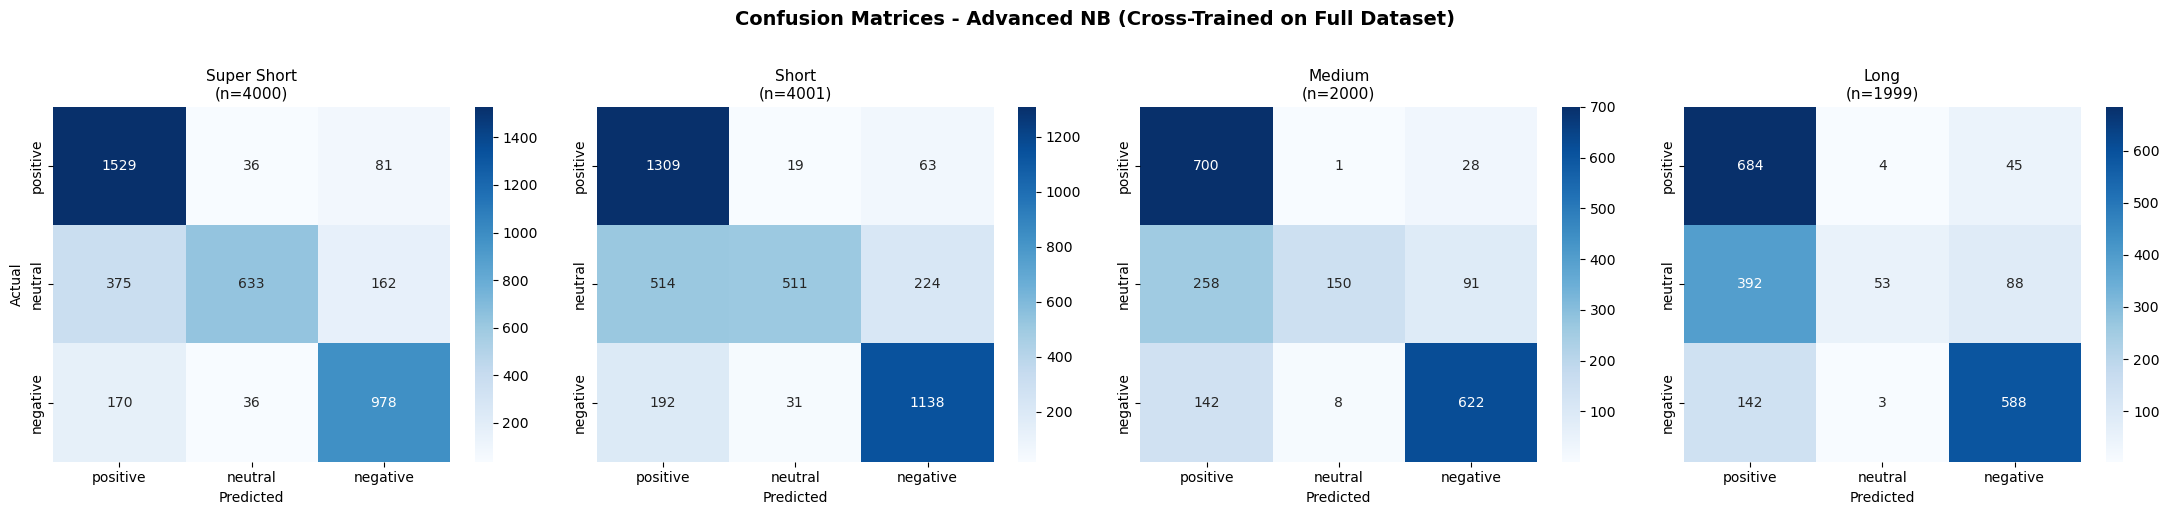

Saved confusion_advanced_nb_cross.png


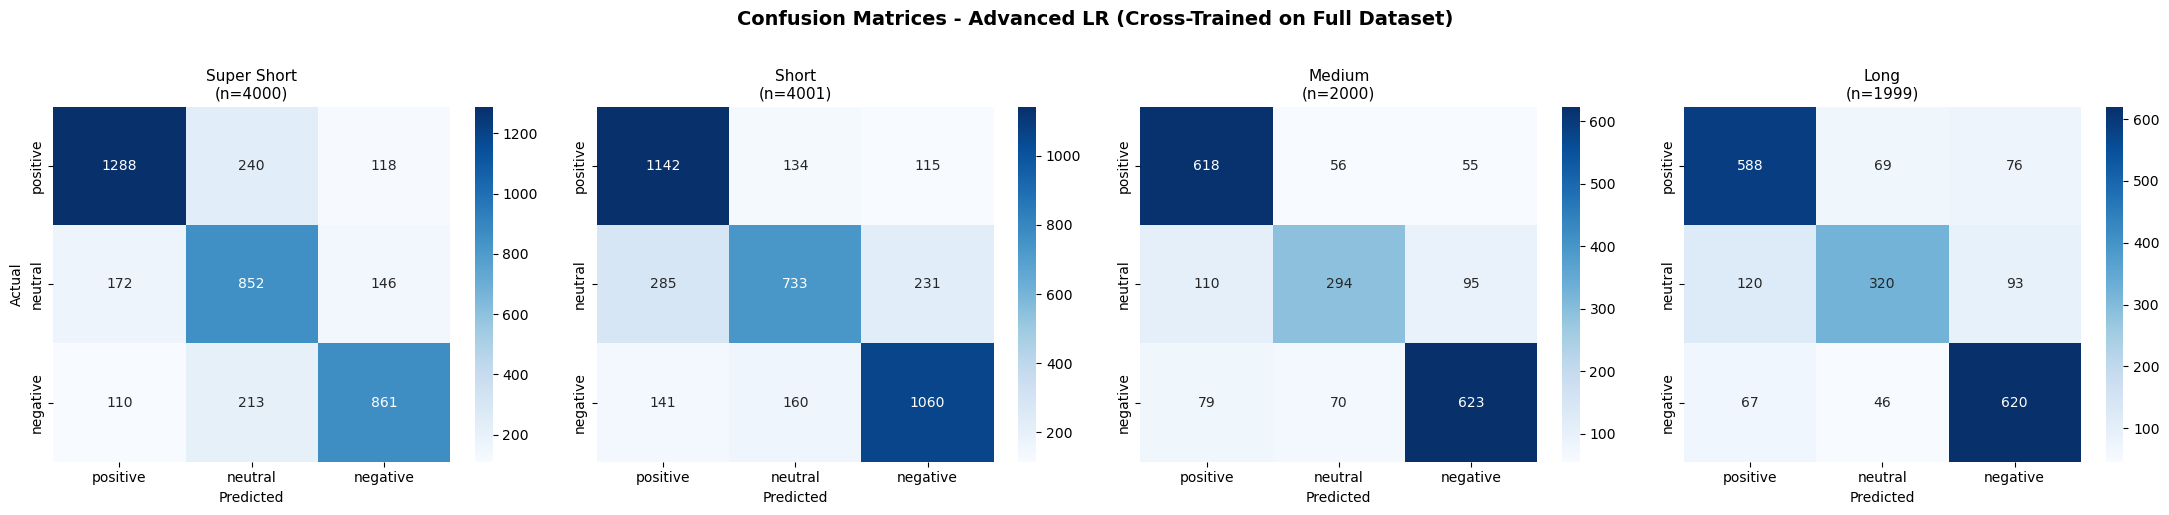

Saved confusion_advanced_lr_cross.png


In [6]:
display_order = ["positive", "neutral", "negative"]

for model_name in ["Advanced NB", "Advanced LR"]:
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle(f"Confusion Matrices - {model_name} (Cross-Trained on Full Dataset)",
                 fontsize=14, fontweight="bold", y=1.02)

    preds = cross_preds[model_name]

    for i, (bucket, ax) in enumerate(zip(bucket_names, axes)):
        mask = test_df["bucket"] == bucket
        y_true_b = y_test[mask]
        y_pred_b = preds[mask]

        cm = confusion_matrix(y_true_b, y_pred_b, labels=display_order)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                    xticklabels=display_order, yticklabels=display_order)
        bucket_title = bucket.replace("_", " ").title()
        ax.set_title(f"{bucket_title}\n(n={mask.sum()})", fontsize=11)
        ax.set_ylabel("Actual" if i == 0 else "")
        ax.set_xlabel("Predicted")

    plt.tight_layout()
    fname = f"confusion_{model_name.lower().replace(' ', '_')}_cross.png"
    plt.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved {fname}")

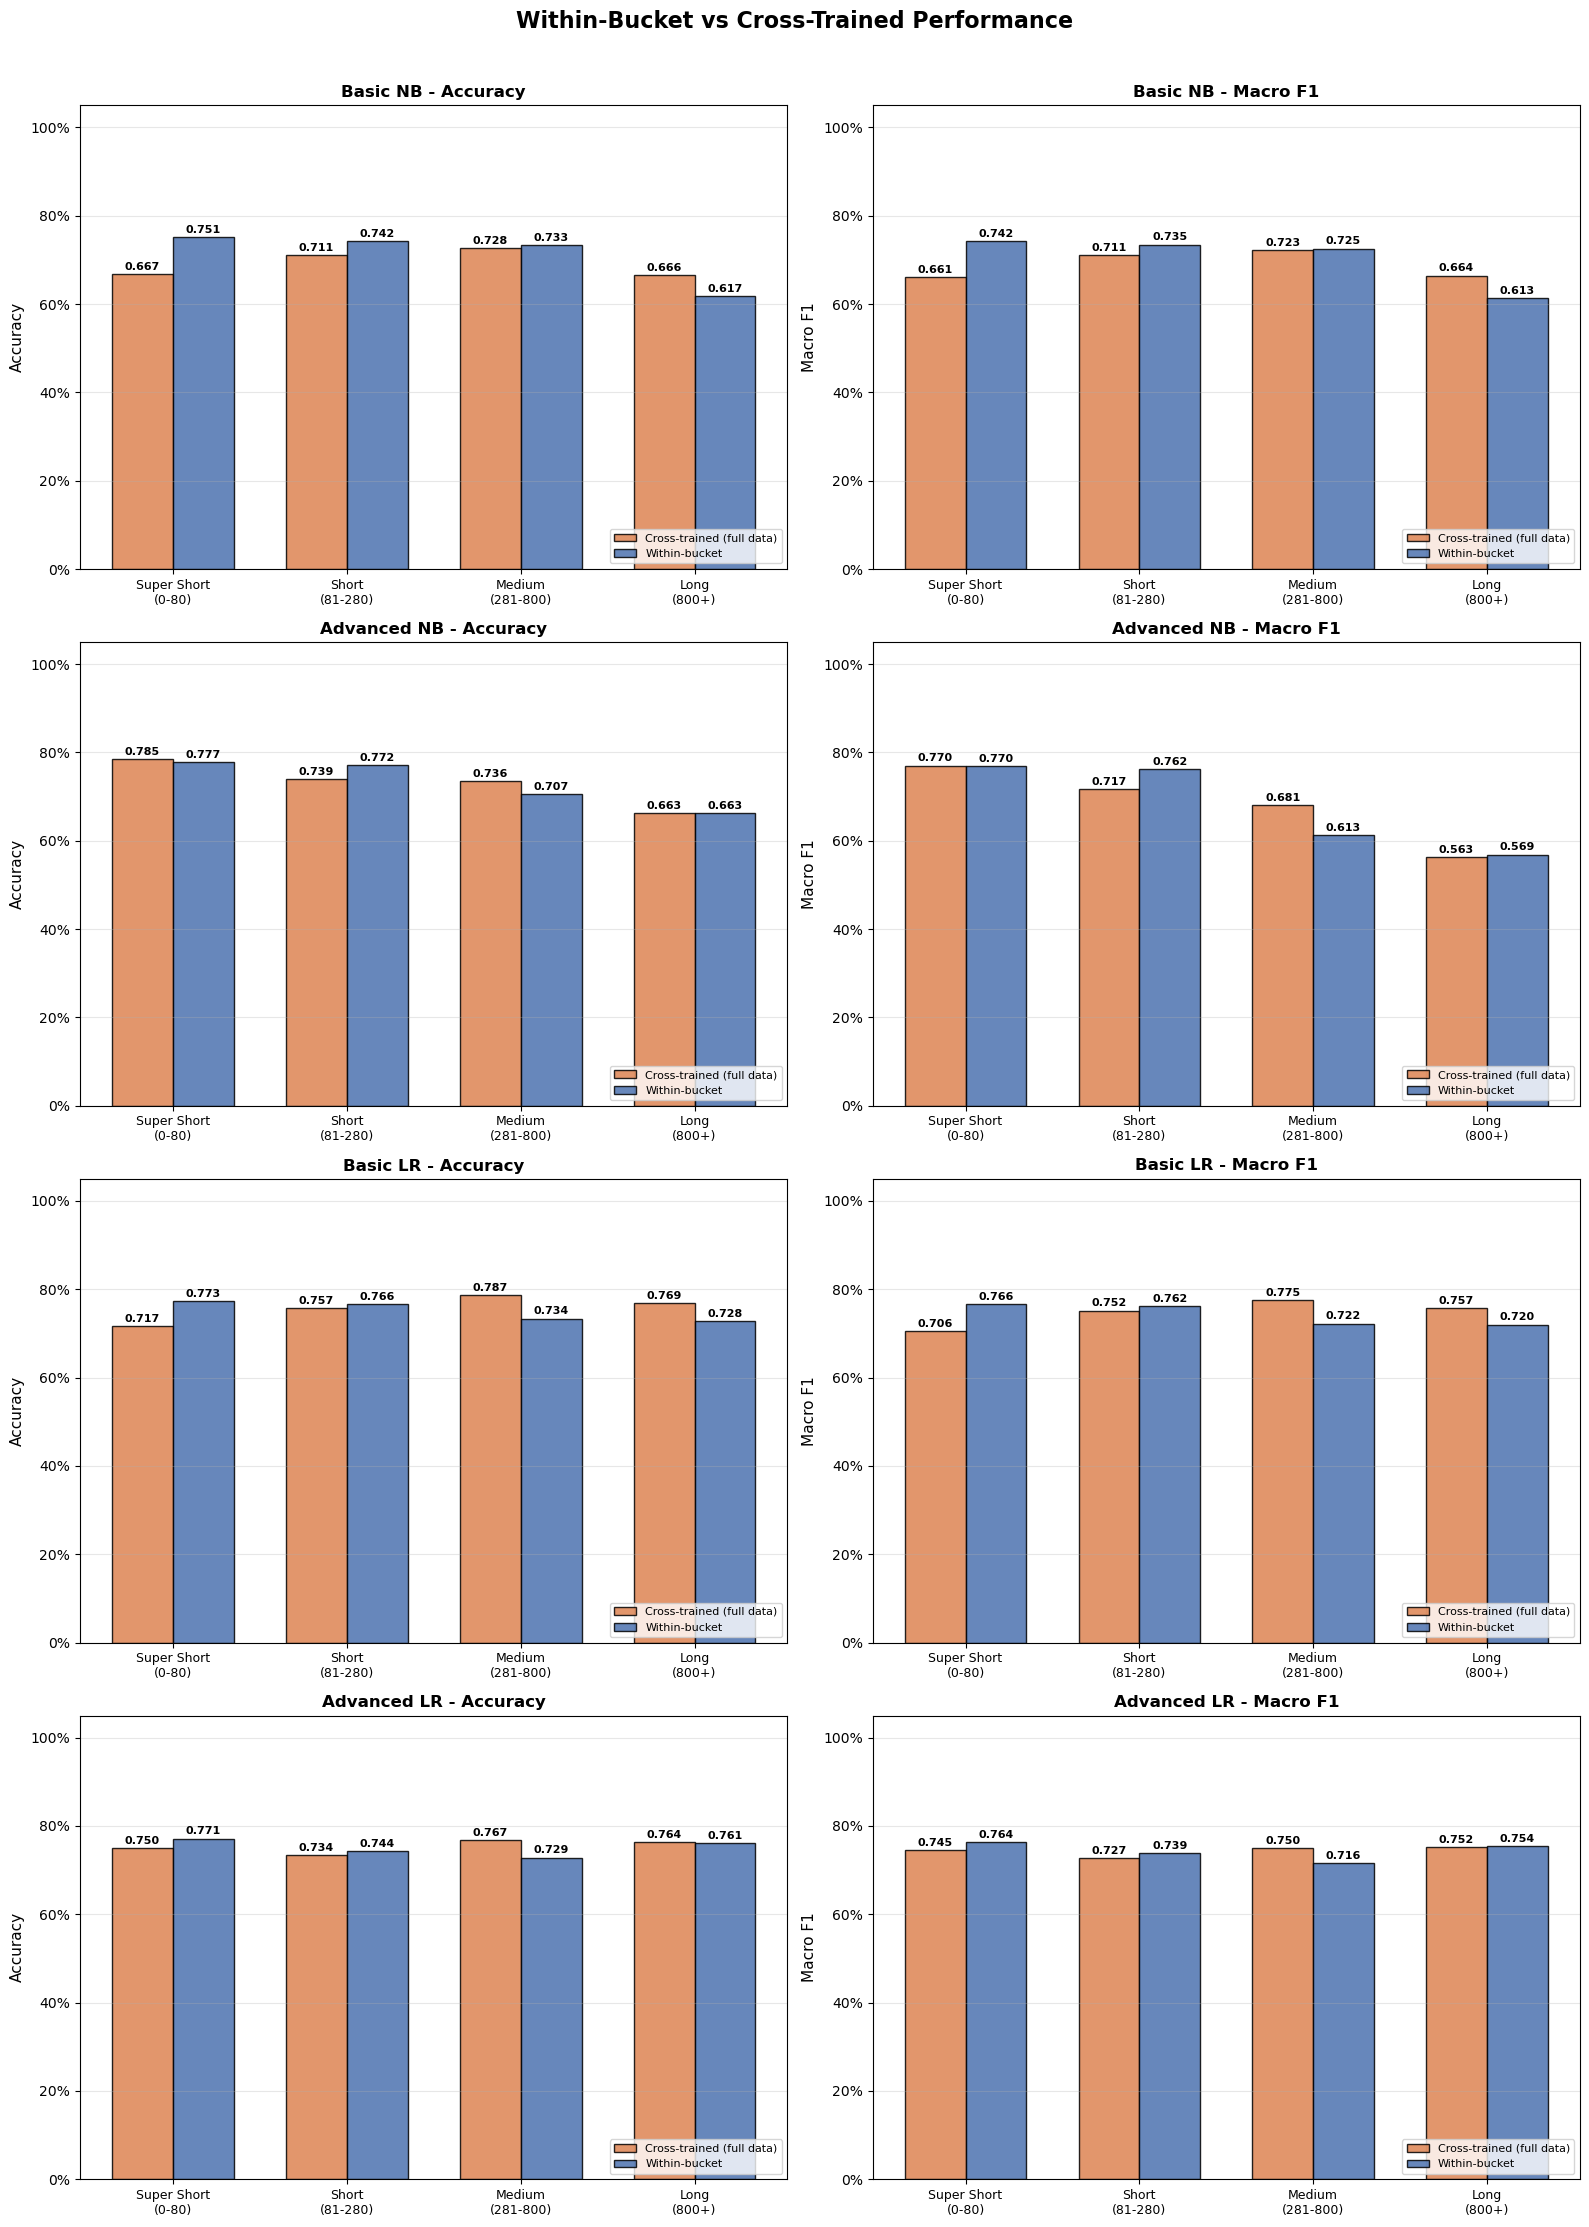

Saved within_vs_cross_comparison.png


In [7]:
fig, axes = plt.subplots(4, 2, figsize=(16, 22))
x = np.arange(len(bucket_names))
width = 0.35

for row, name in enumerate(model_names):
    for col, (metric_key, metric_label) in enumerate([("acc", "Accuracy"), ("f1", "Macro F1")]):
        ax = axes[row, col]
        bars1 = ax.bar(x - width/2, cross_results[name][metric_key], width,
                       label="Cross-trained (full data)", color="#DD8452", edgecolor="black", alpha=0.85)
        bars2 = ax.bar(x + width/2, within_results[name][metric_key], width,
                       label="Within-bucket", color="#4C72B0", edgecolor="black", alpha=0.85)
        for bar in list(bars1) + list(bars2):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(bucket_labels, fontsize=9)
        ax.set_ylabel(metric_label, fontsize=11)
        ax.set_title(f"{name} - {metric_label}", fontsize=12, fontweight="bold")
        ax.set_ylim(0, 1.05)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
        ax.legend(fontsize=8, loc="lower right")
        ax.grid(axis="y", alpha=0.3)

plt.suptitle("Within-Bucket vs Cross-Trained Performance", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("within_vs_cross_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved within_vs_cross_comparison.png")

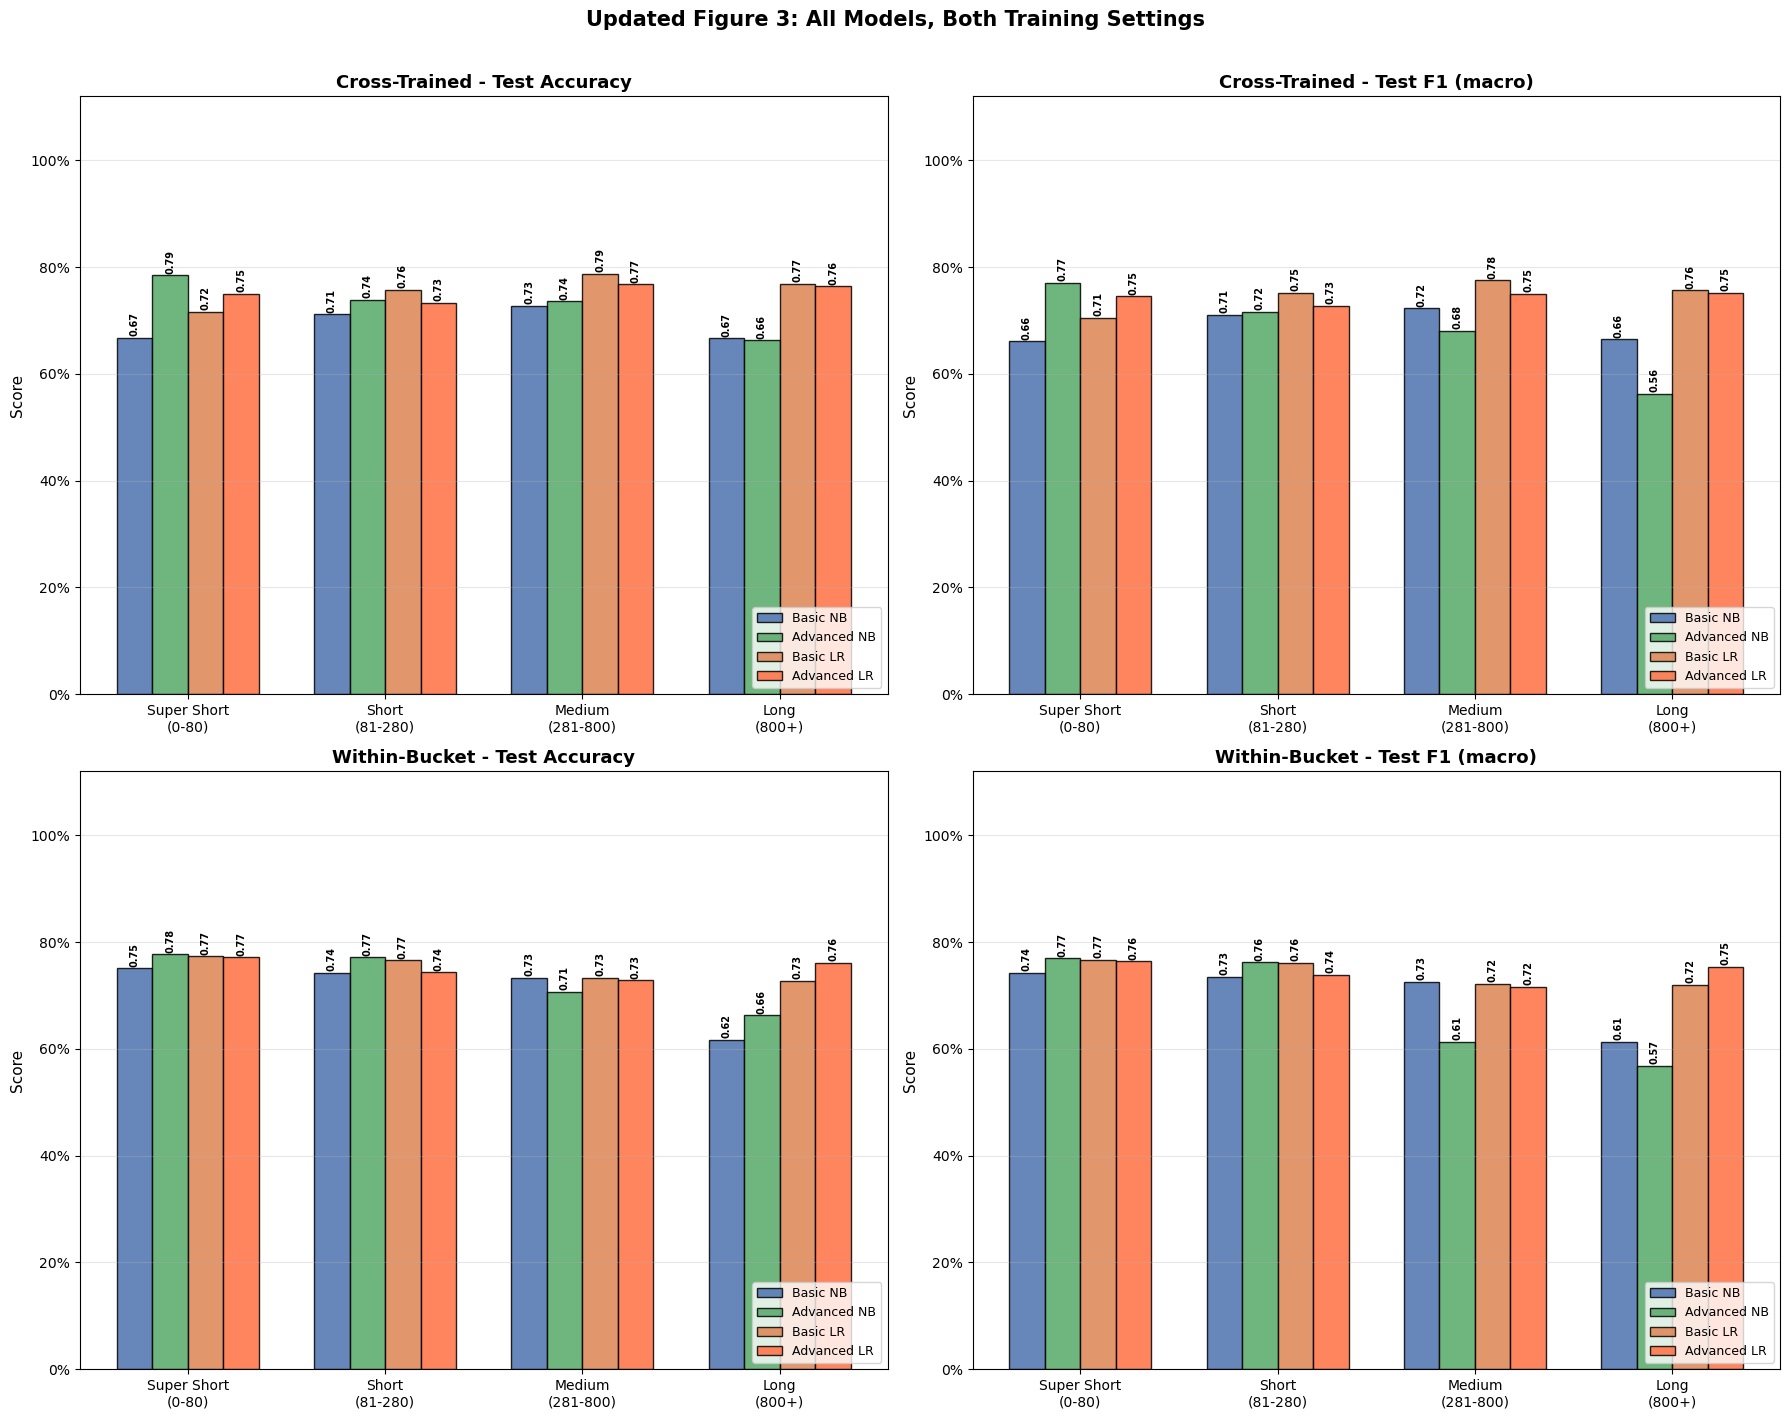

Saved updated_figure3.png


In [8]:
colors_map = {"Basic NB": "#4C72B0", "Advanced NB": "#55A868",
              "Basic LR": "#DD8452", "Advanced LR": "#FF7043"}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
x = np.arange(len(bucket_names))
width = 0.18
n = len(model_names)
offsets = np.arange(n) - (n - 1) / 2

configs = [
    ("Cross-Trained - Test Accuracy", "acc", cross_results),
    ("Cross-Trained - Test F1 (macro)", "f1", cross_results),
    ("Within-Bucket - Test Accuracy", "acc", within_results),
    ("Within-Bucket - Test F1 (macro)", "f1", within_results),
]

for idx, (title, key, results) in enumerate(configs):
    ax = axes[idx // 2, idx % 2]
    for i, name in enumerate(model_names):
        bars = ax.bar(x + offsets[i] * width, results[name][key], width,
                      label=name, color=colors_map[name], edgecolor="black", alpha=0.85)
        for bar in bars:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f"{bar.get_height():.2f}", ha="center", va="bottom",
                    fontsize=7, fontweight="bold", rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(bucket_labels, fontsize=10)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.12)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Updated Figure 3: All Models, Both Training Settings",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("updated_figure3.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved updated_figure3.png")

In [9]:
rows = []
for name in model_names:
    for i, bucket in enumerate(bucket_names):
        rows.append({
            "model": name,
            "bucket": bucket,
            "cross_acc": round(cross_results[name]["acc"][i], 4),
            "cross_f1": round(cross_results[name]["f1"][i], 4),
            "within_acc": round(within_results[name]["acc"][i], 4),
            "within_f1": round(within_results[name]["f1"][i], 4),
            "diff_acc": round(cross_results[name]["acc"][i] - within_results[name]["acc"][i], 4),
            "diff_f1": round(cross_results[name]["f1"][i] - within_results[name]["f1"][i], 4),
        })

results_df = pd.DataFrame(rows)
results_df.to_csv("lr_nb_all_results.csv", index=False)
print("Saved lr_nb_all_results.csv")
print(results_df.to_string(index=False))

Saved lr_nb_all_results.csv
      model      bucket  cross_acc  cross_f1  within_acc  within_f1  diff_acc  diff_f1
   Basic NB super_short     0.6673    0.6612      0.7508     0.7420   -0.0835  -0.0807
   Basic NB       short     0.7113    0.7110      0.7421     0.7348   -0.0307  -0.0237
   Basic NB      medium     0.7275    0.7230      0.7330     0.7254   -0.0055  -0.0025
   Basic NB        long     0.6663    0.6644      0.6173     0.6130    0.0490   0.0514
Advanced NB super_short     0.7850    0.7702      0.7775     0.7698    0.0075   0.0004
Advanced NB       short     0.7393    0.7167      0.7718     0.7622   -0.0325  -0.0455
Advanced NB      medium     0.7360    0.6812      0.7065     0.6133    0.0295   0.0679
Advanced NB        long     0.6628    0.5629      0.6628     0.5688    0.0000  -0.0058
   Basic LR super_short     0.7165    0.7055      0.7732     0.7664   -0.0567  -0.0609
   Basic LR       short     0.7571    0.7517      0.7656     0.7618   -0.0085  -0.0101
   Basic LR    